# Homework


The homework is to prepare a report for the Ministry of Transport, revealing the nature and characteristics of flight delays. The report should help identify problem areas and contribute to decision-making. Therefore, strive not to state general facts, but to show problems. For example, the fact "the average departure delay is 15 minutes" by itself says little and does not help to understand why this is happening. On the contrary, a graph showing that on Mondays delays increase threefold compared to other days against the background of an increase in the number of flights and passengers suggests a possible cause of the problem: airports cannot cope with uneven load.

The report should be in the form of a notebook with a clear structure. At the beginning of the Markdown cell there is a brief description of the question under study (what we will study), then the code and all its outputs (tables, graphs, values), then again in the Markdown cell in which your brief conclusion is formulated.

The report should contain at least **5 results** confirmed by graphs. For variety of material, use different types of diagrams. All graphs should be provided with the necessary signatures (axis designations, title, color scheme legend).

To solve the problems, use the methods of the `pandas` library.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [3]:
from google.colab import drive
drive.mount('/content/drive')



Mounted at /content/drive


In [4]:
#!ls /content/drive/MyDrive/
df_airports = pd.read_csv("/content/drive/MyDrive/Copy of airports.csv", low_memory=False)
df_flights = pd.read_csv("/content/drive/MyDrive/Copy of flights.csv", low_memory=False)
df_airlines = pd.read_csv("/content/drive/MyDrive/Copy of airlines.csv", low_memory=False)

In [6]:
print("AIRPORTS")
display(df_airports.head())

AIRPORTS


,IATA_CODE,AIRPORT,CITY,STATE,COUNTRY,LATITUDE,LONGITUDE
0,ABE,Lehigh Valley International Airport,Allentown,PA,USA,40.65236,-75.44040
1,ABI,Abilene Regional Airport,Abilene,TX,USA,32.41132,-99.68190
2,ABQ,Albuquerque International Sunport,Albuquerque,NM,USA,35.04022,-106.60919
3,ABR,Aberdeen Regional Airport,Aberdeen,SD,USA,45.44906,-98.42183
4,ABY,Southwest Georgia Regional Airport,Albany,GA,USA,31.53552,-84.19447


In [7]:
print("AIRLINES")
display(df_airlines.head())


AIRLINES


,IATA_CODE,AIRLINE
0,UA,United Air Lines Inc.
1,AA,American Airlines Inc.
2,US,US Airways Inc.
3,F9,Frontier Airlines Inc.
4,B6,JetBlue Airways


In [8]:
print("FLIGHTS")
display(df_flights.head())

FLIGHTS


,YEAR,MONTH,DAY,DAY_OF_WEEK,AIRLINE,FLIGHT_NUMBER,TAIL_NUMBER,ORIGIN_AIRPORT,DESTINATION_AIRPORT,SCHEDULED_DEPARTURE,...,ARRIVAL_TIME,ARRIVAL_DELAY,DIVERTED,CANCELLED,CANCELLATION_REASON,AIR_SYSTEM_DELAY,SECURITY_DELAY,AIRLINE_DELAY,LATE_AIRCRAFT_DELAY,WEATHER_DELAY
0,2015,1,1,4,AS,98,N407AS,ANC,SEA,5,...,408.0,-22.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
1,2015,1,1,4,AA,2336,N3KUAA,LAX,PBI,10,...,741.0,-9.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
2,2015,1,1,4,US,840,N171US,SFO,CLT,20,...,811.0,5.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
3,2015,1,1,4,AA,258,N3HYAA,LAX,MIA,20,...,756.0,-9.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,2015,1,1,4,AS,135,N527AS,SEA,ANC,25,...,259.0,-21.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN


In [9]:
print(df_flights.columns)

Index(['YEAR', 'MONTH', 'DAY', 'DAY_OF_WEEK', 'AIRLINE', 'FLIGHT_NUMBER',
       'TAIL_NUMBER', 'ORIGIN_AIRPORT', 'DESTINATION_AIRPORT',
       'SCHEDULED_DEPARTURE', 'DEPARTURE_TIME', 'DEPARTURE_DELAY', 'TAXI_OUT',
       'WHEELS_OFF', 'SCHEDULED_TIME', 'ELAPSED_TIME', 'AIR_TIME', 'DISTANCE',
       'WHEELS_ON', 'TAXI_IN', 'SCHEDULED_ARRIVAL', 'ARRIVAL_TIME',
       'ARRIVAL_DELAY', 'DIVERTED', 'CANCELLED', 'CANCELLATION_REASON',
       'AIR_SYSTEM_DELAY', 'SECURITY_DELAY', 'AIRLINE_DELAY',
       'LATE_AIRCRAFT_DELAY', 'WEATHER_DELAY'],
      dtype='object')


In [10]:
df_flights.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5819079 entries, 0 to 5819078
Data columns (total 31 columns):
 #   Column               Dtype  
---  ------               -----  
 0   YEAR                 int64  
 1   MONTH                int64  
 2   DAY                  int64  
 3   DAY_OF_WEEK          int64  
 4   AIRLINE              object 
 5   FLIGHT_NUMBER        int64  
 6   TAIL_NUMBER          object 
 7   ORIGIN_AIRPORT       object 
 8   DESTINATION_AIRPORT  object 
 9   SCHEDULED_DEPARTURE  int64  
 10  DEPARTURE_TIME       float64
 11  DEPARTURE_DELAY      float64
 12  TAXI_OUT             float64
 13  WHEELS_OFF           float64
 14  SCHEDULED_TIME       float64
 15  ELAPSED_TIME         float64
 16  AIR_TIME             float64
 17  DISTANCE             int64  
 18  WHEELS_ON            float64
 19  TAXI_IN              float64
 20  SCHEDULED_ARRIVAL    int64  
 21  ARRIVAL_TIME         float64
 22  ARRIVAL_DELAY        float64
 23  DIVERTED             int64  
 24

In [11]:
df_flights.isna().sum().sort_values(ascending=False)

,0
CANCELLATION_REASON,5729195
LATE_AIRCRAFT_DELAY,4755640
WEATHER_DELAY,4755640
AIRLINE_DELAY,4755640
AIR_SYSTEM_DELAY,4755640
SECURITY_DELAY,4755640
ELAPSED_TIME,105071
AIR_TIME,105071
ARRIVAL_DELAY,105071
WHEELS_ON,92513


**1. Анализ задержек по месяцам**

Сначала посмотрим, как средняя задержка зависит от вылета. Мы сможем выявить сезонные закономерности, которые потенциально могут быть связаны с погодными условиямии или другими причинами


In [12]:
monthly_delay = (df_flights.groupby('MONTH')['DEPARTURE_DELAY'])

mean_monthly_delay = monthly_delay.mean()
print(mean_monthly_delay )



MONTH
1      9.759471
2     11.885284
3      9.660903
4      7.721885
5      9.454144
6     13.986016
7     11.394664
8      9.932045
9      4.823560
10     4.982661
11     6.944197
12    11.783529
Name: DEPARTURE_DELAY, dtype: float64


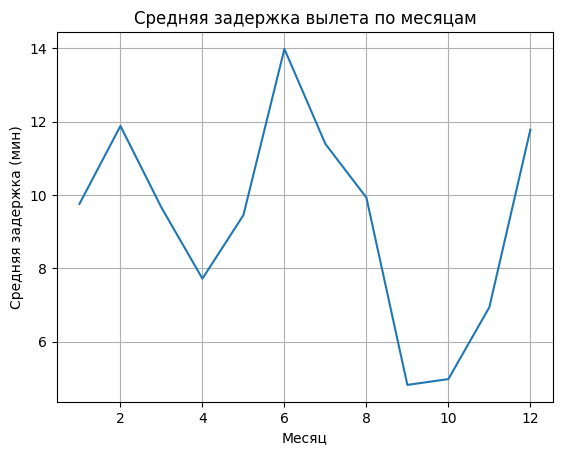

In [13]:
plt.plot(mean_monthly_delay.index, mean_monthly_delay.values)
plt.xlabel("Месяц")
plt.ylabel("Средняя задержка (мин)")
plt.title("Средняя задержка вылета по месяцам")

plt.grid(True)
plt.show()

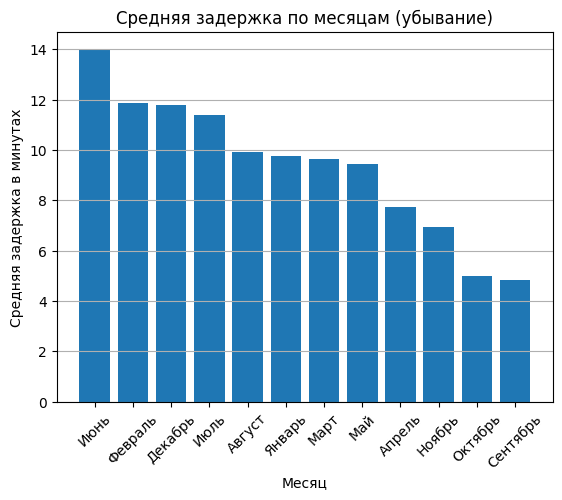

In [14]:
month_names = ['Январь', 'Февраль', 'Март', 'Апрель', 'Май', 'Июнь', 'Июль', 'Август', 'Сентябрь', 'Октябрь', 'Ноябрь', 'Декабрь']

mean_sorted_monthly = mean_monthly_delay.sort_values(ascending = False)

#print(mean_sorted_monthly)

sorted_months = [month_names[i - 1] for i in mean_sorted_monthly.index]

plt.bar(sorted_months, mean_sorted_monthly.values)

plt.xlabel("Месяц")
plt.ylabel("Средняя задержка в минутах")
plt.title("Средняя задержка по месяцам (убывание)")

plt.xticks(fontsize = 10, rotation = 45)
plt.grid(axis = 'y')
plt.show()


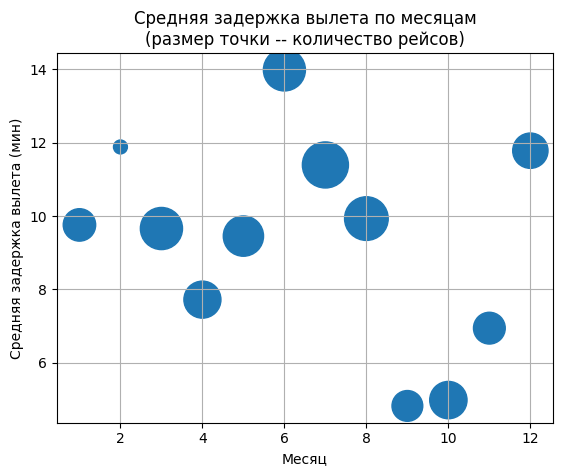

In [15]:
monthly_flights = (df_flights.groupby('MONTH').size())

siz = (monthly_flights - monthly_flights.min())/(monthly_flights.max() - monthly_flights.min())

plt.scatter(mean_monthly_delay.index, mean_monthly_delay.values, s = 100 +siz*1000)

plt.xlabel("Месяц")
plt.ylabel("Средняя задержка вылета (мин)")
plt.title("Средняя задержка вылета по месяцам\n(размер точки -- количество рейсов)")


plt.grid(True)
plt.show()

Заметим, что наибольшие задержки наблюдаются летом/зимой. Зимой задержки объяснимы плохими погодными условиями. А летом задержки объяснимы растущиму потком людей (пусть и относительно небольшим), которые едут в отпуск.
Для снижения задержек стоит сфокусироваться на улучшении инфраструктуры аэропортов при растущем летнем трафике. В зимнее время года стоит задуматься над устойчивостью аэропортов к погодным условиям.
Например, февраль входит в топ 2 месяца по задержке, однако имеет наименьшее количество рейсов.


**2. Аэропорты**

Исследуем связь задержек с конкретными аэропортами. Важно понять, являются ли длительные задержки следствием плохого устройства аэропортов и неспособностью их пропускать нужное количество человек


In [16]:
airport_delay = (df_flights.groupby('ORIGIN_AIRPORT')['DEPARTURE_DELAY'])

mean_airport_delay = airport_delay.mean().sort_values(ascending=False)

print(mean_airport_delay)
#print(f'Количество аэропортов: {df_flights['ORIGIN_AIRPORT'].nunique()}')

print(f'Средняя задержка по всем аэропортам: {mean_airport_delay.mean()}\nМедиана: {mean_airport_delay.median()}')

ORIGIN_AIRPORT
14222    89.111111
ILG      29.391753
13964    28.843750
MVY      25.907317
HYA      23.182927
           ...    
YAK      -6.292237
14113    -6.649123
12511    -6.689655
12519    -8.253333
11503    -8.500000
Name: DEPARTURE_DELAY, Length: 628, dtype: float64
Средняя задержка по всем аэропортам: 5.587101521283507
Медиана: 5.44469294730515


In [17]:
print(f'Количество аэропортов, у которых задержка более 6 минут: {(mean_airport_delay>6).sum()}')

Количество аэропортов, у которых задержка более 6 минут: 283


In [18]:
print(f'Количество аэропортов, у которых задержка более 10 минут: {(mean_airport_delay>10).sum()}')

Количество аэропортов, у которых задержка более 10 минут: 86


In [19]:
print(f'Количество аэропортов, у которых задержка более 15 минут: {(mean_airport_delay>15).sum()}')

Количество аэропортов, у которых задержка более 15 минут: 20


Хотим сделать анализ аэропортов, у которых самые длинные задержки, при это важно сделать акцент на аэропорты с большим количеством рейсов


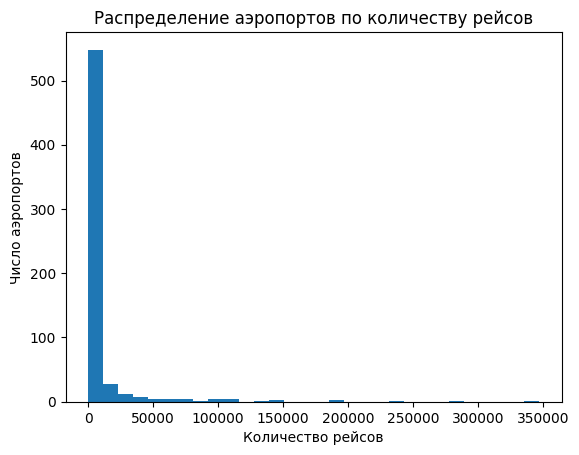

In [20]:
airport_counts = (df_flights['ORIGIN_AIRPORT'].value_counts())

plt.hist((airport_counts), bins = 30)
plt.xlabel("Количество рейсов")
plt.ylabel("Число аэропортов")
plt.title("Распределение аэропортов по количеству рейсов")

plt.show()


In [21]:
print(f'Колиичество аэропортов, у которых рейсов больше 50к: {(airport_counts>50000).sum()}')

Колиичество аэропортов, у которых рейсов больше 50к: 29


In [22]:
airport_stats = pd.DataFrame({'flights_count': airport_counts, 'mean_delay': mean_airport_delay})



print(f'Колиичество аэропортов, у которых рейсов больше 50к и задержки более 15 минут: {((airport_stats['flights_count']>50000) & (airport_stats['mean_delay']>15)).sum()}')

Колиичество аэропортов, у которых рейсов больше 50к и задержки более 15 минут: 0


По гистограмме видно, что большинство аэропортов имеют достаточно маленькое количество рейсов в среднем. Также мы ранее выводили информацию, что есть 20 аэропортов, у которых задержка более 15 минут. Казалось, что это может быть напрямую связано с количество рейсов. Однако оказалось, что ни один из 29 аэропортов с крупнейшими пропускными способностями не задерживает свои рейсы в среднем более чем на 15 минут


Попробуем выснить, в чем характерные особенности аэропортов с самой длинной задержкой

---



In [23]:
top20_delay_airports = mean_airport_delay.head(20)

print(top20_delay_airports)

ORIGIN_AIRPORT
14222    89.111111
ILG      29.391753
13964    28.843750
MVY      25.907317
HYA      23.182927
10154    22.857143
10581    20.111111
STC      18.692308
OTH      17.777358
ASE      17.587538
10165    17.555556
14025    17.538462
CEC      17.413793
GST      17.171053
BPT      17.020856
GUM      16.647590
ACK      16.388889
UST      16.368056
EGE      15.744398
PPG      15.102804
Name: DEPARTURE_DELAY, dtype: float64


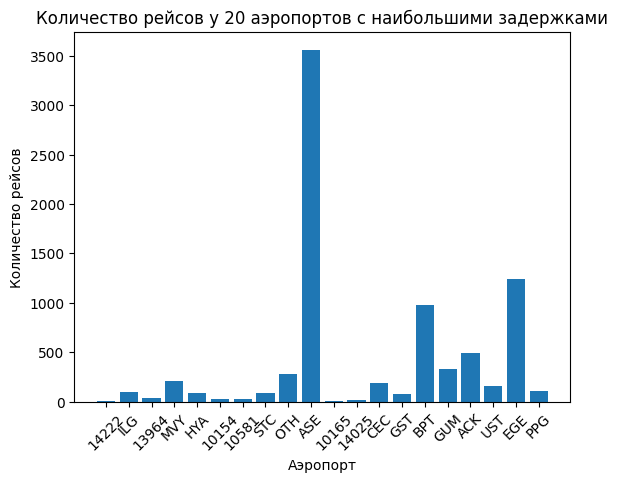

In [24]:
top20_counts = airport_counts.loc[top20_delay_airports.index]

plt.bar(top20_counts.index, top20_counts.values)
plt.xlabel("Аэропорт")
plt.ylabel("Количество рейсов")
plt.title("Количество рейсов у 20 аэропортов с наибольшими задержками")
plt.xticks(rotation=45)

plt.show()


По данному графику видно, что аэропорты с наибольшими задержками в среднем имеют небольшое количество рейсов. А значит, они выбиваются из статистики из-за отедльных крупных сбоев

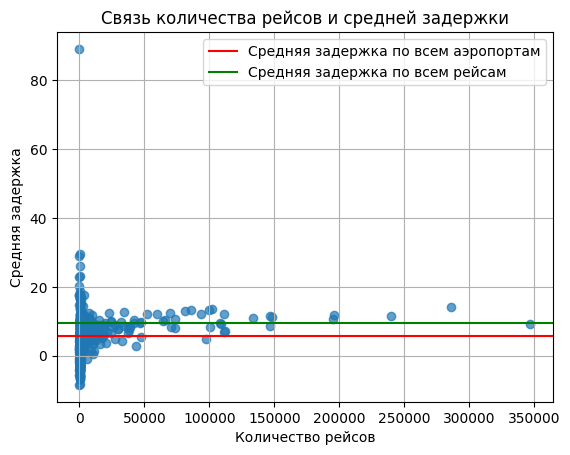

In [25]:
plt.scatter(airport_stats['flights_count'], airport_stats['mean_delay'], alpha=0.7)

plt.xlabel("Количество рейсов")
plt.ylabel("Средняя задержка")
plt.title("Связь количества рейсов и средней задержки")
plt.axhline(y=mean_airport_delay.mean(), c = 'red',label='Средняя задержка по всем аэропортам')
plt.axhline(y=df_flights['DEPARTURE_DELAY'].mean(), color='green',label='Средняя задержка по всем рейсам')

plt.grid(True)
plt.legend()
plt.show()

Подведем итог анализа аэропортов. Анализ показал, что высокая задержка рейсов не обязательно связана с большим количеством рейсов. Более того, крупные аэропорты не сильно выбиваются из общей картины и показывают цифры близкие к средним.

Таким образом, причины задержек следует искать не только в загруженности аэропортов.


**3. Анализ причин задержек**

Хотим понять, какие причины дают наибольший вклад в задержки как по длительности, так и по количеству.

In [26]:
delay_reasons = df_flights[['WEATHER_DELAY', 'AIRLINE_DELAY', 'AIR_SYSTEM_DELAY', 'SECURITY_DELAY', 'LATE_AIRCRAFT_DELAY']]
print(delay_reasons.mean())

WEATHER_DELAY           2.915290
AIRLINE_DELAY          18.969547
AIR_SYSTEM_DELAY       13.480568
SECURITY_DELAY          0.076154
LATE_AIRCRAFT_DELAY    23.472838
dtype: float64


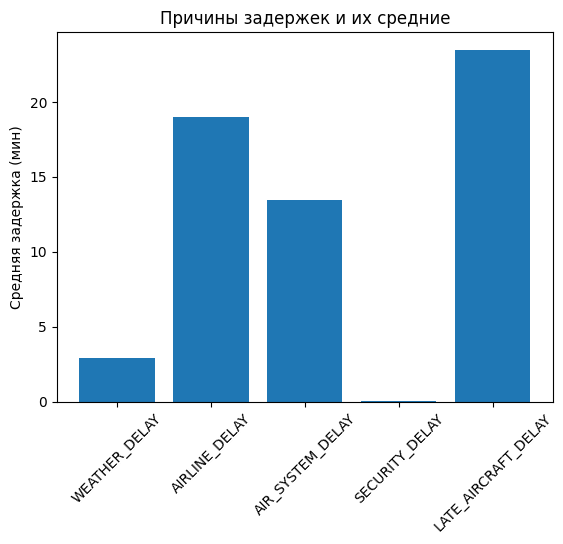

In [32]:
mean_delay_reasons = delay_reasons.mean()
plt.bar(mean_delay_reasons.index, mean_delay_reasons.values)

plt.ylabel("Средняя задержка (мин)")
plt.title("Причины задержек и их средние")
plt.xticks(rotation = 45)

plt.show()

In [37]:
delay_reasons_counts = [(df_flights['WEATHER_DELAY'] > 0).sum(), (df_flights['AIRLINE_DELAY']>0).sum(), (df_flights['AIR_SYSTEM_DELAY'] > 0).sum(), (df_flights['SECURITY_DELAY'] > 0).sum(), (df_flights['LATE_AIRCRAFT_DELAY'] > 0).sum()]

reasons_names = ['Погода','Авиакомпания','Система','Безопасность','Поздний рейс']

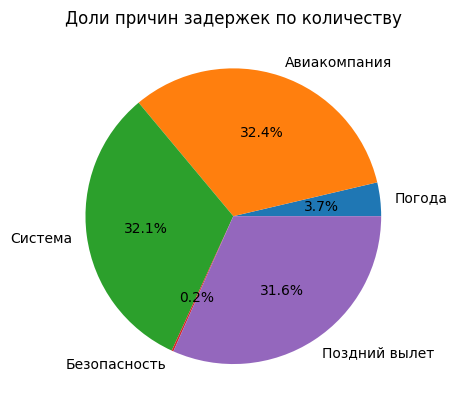

In [44]:
plt.pie(delay_reasons_counts, labels=reasons_names, autopct='%1.1f%%')

plt.title("Доли причин задержек по количеству")
plt.show()

Видно, что как по количеству, так и по длительности задержки доминируют системные проблемы, поздние рейсы и задержки, вызванные авиакомпаниями.
Для оптимизиции необходимо сфокусироваться на изменении в расписании поздних рейсов, а также оптимизацией частоты поздних рейсов.
Также стоит улучшить взаимодействия между авиакомпаниями и аэропортами, так как в львиной доле длинных задержек виноваты авиакомпании.
Не стоит забывать и про большое количество системных ошибок, стоит поработать над устойчивостью системы.



**4. Авиакомпании, на которые нужно сделать акцент**

Ранее мы выяснили, что часть задержек связана именно с авиакомпаниями. Выясним, является ли эта проблема системной или есть отдельные компании, которым стоит улучшить внутренние процесс.


In [47]:
airline_delay = (df_flights.groupby('AIRLINE')['DEPARTURE_DELAY'])
mean_airline_delay = airline_delay.mean()

print(mean_airline_delay)

AIRLINE
AA     8.900856
AS     1.785801
B6    11.514353
DL     7.369254
EV     8.715934
F9    13.350858
HA     0.485713
MQ    10.125188
NK    15.944766
OO     7.801104
UA    14.435441
US     6.141137
VX     9.022595
WN    10.581986
Name: DEPARTURE_DELAY, dtype: float64


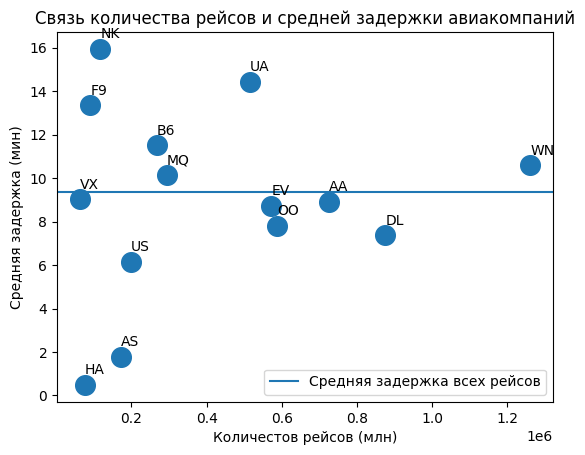

In [89]:
airline_counts = df_flights['AIRLINE'].value_counts()

airline_stats = pd.DataFrame({'Количество рейсов': airline_counts, 'Средняя задержка': mean_airline_delay } )

x = airline_stats['Количество рейсов']
y = airline_stats['Средняя задержка']

plt.scatter(x, y, s=200)
plt.xlabel("Количестов рейсов (млн)")
plt.ylabel("Средняя задержка (мин)")

for airline in airline_stats.index:
  plt.text(x[airline], y[airline]+0.5, airline)

plt.axhline(y = df_flights['DEPARTURE_DELAY'].mean(), label='Средняя задержка всех рейсов')

plt.legend()
plt.title("Связь количества рейсов и средней задержки авиакомпаний")
plt.show()

Заметим, что явной зависимости между количеством рейсов и средней задержки нет, однако, достаточно много маленьких компаний (количество рейсов до 500к), которые являются лидерами по средней задержке.
Также крупнейшая авиакомпания (WN) задерживает рейсы больше среднего.

Стоит провести более подробный анализ, который поможет маленьким компаниям не выпадать из общей картины.
Также необходимо понять, в чем проблемы лидера по количеству рейсов.


**5.Проанализируем время суток**

Исследуем зависимость задержек от времени вылета. Можно ожидать, что задержки будут иметь накопительный эффект, как следствие, вечерние рейсы будут сильно задерживаться

In [85]:

df_flights['HOUR'] = df_flights['SCHEDULED_DEPARTURE'] // 100

hour_delay = (df_flights.groupby('HOUR')['DEPARTURE_DELAY'])

mean_hour_delay = hour_delay.mean()

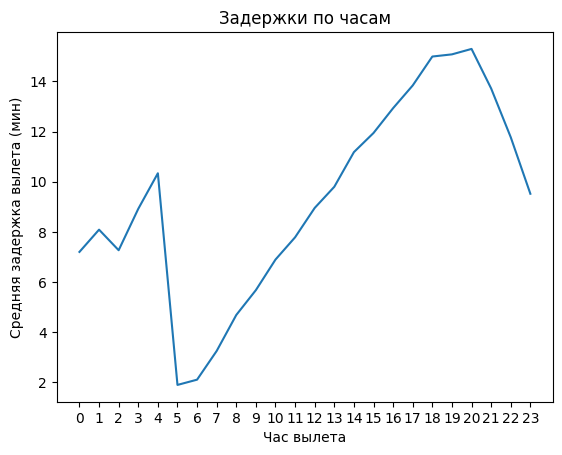

In [90]:
plt.plot(mean_hour_delay.index, mean_hour_delay.values)

plt.xlabel("Час вылета")
plt.ylabel("Средняя задержка вылета (мин)")


plt.title("Задержки по часам")
plt.xticks(range(0,24))
plt.show()

По графику видно, что к вечеру задержка рейсов увеличивается. Это происходит равномерно, что является индикатором накомпительного эффекта.
Для решения данной проблемы стоит задумать о пересмотре расписания внутри дня.
Также на графике наблюдается скачок в ноьчю и резкое падение к рассвету. Скорее всего это связано с плохой видимостью и большими мерами предосторожности.
Для улучшения статистики необходимо повысить устойчивость аэропортов к работе в ночных условиях.